# **Project Overview**

**Problem Statement**

**Business Objective**

**Dataset Description**

## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

## **2. Load and Explore Dataset**

**Load CSV and Display Dataset**

In [2]:
df = pd.read_csv('data/PS_20174392719_1491204439457_log.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


**Display Shape**

In [3]:
df.shape

(6362620, 11)

**Display Dataset Info**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


**Drop ID Coloumns and isFlaggedFraud**

In [5]:
df = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

**Count Null Values**

In [6]:
df.isna().sum()

step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

**Count Duplicates**

In [7]:
df.duplicated().sum()

np.int64(543)

In [8]:
df = df.drop_duplicates()

**Summary Statistics**

In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,6362077.0,NaN,NaN,NaN,243.399529,142.33233,1.0,156.0,239.0,335.0,743.0
type,6362077,5,CASH_OUT,2237484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,6362077.0,NaN,NaN,NaN,179853.072675,603693.667054,0.0,13394.07,74893.34,208732.96,92445516.64
oldbalanceOrg,6362077.0,NaN,NaN,NaN,833930.698363,2888321.643696,0.0,0.0,14218.0,107326.0,59585040.37
newbalanceOrig,6362077.0,NaN,NaN,NaN,855186.65209,2924162.611142,0.0,0.0,0.0,144292.52,49585040.37
oldbalanceDest,6362077.0,NaN,NaN,NaN,1100795.610841,3399309.958137,0.0,0.0,132783.41,943171.77,356015889.35
newbalanceDest,6362077.0,NaN,NaN,NaN,1225077.373809,3674244.077873,0.0,0.0,214738.54,1112050.52,356179278.92
isFraud,6362077.0,NaN,NaN,NaN,0.001288,0.035871,0.0,0.0,0.0,0.0,1.0


## **3. EDA**

In [39]:
df_eda = df.copy()

**Check Target Distibution for Imbalance**

The target variable is highly imbalanced, with 99.9% legitimate transactions and 0.1% fraudulent transactions. This distribution is typical of real-world fraud detection datasets and is expected for this type of problem.

In [40]:
counts = df_eda['isFraud'].value_counts()
pct = df_eda['isFraud'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'count': counts, 'pct': pct.round(2)})

summary

,count,pct
isFraud,,
0,6353880,99.87
1,8197,0.13


**Transaction Type vs Fraud**

Fraudulent transaction can be observed only in `TRANSFER` and `CASH_OUT` transactiontypes. No fraud cases were recored for `PAYMENT`, `DEBIT`, or `CASH_IN`, suggesting that fraudlent activities in this dataset only happens in money transfers and cash withdrawals.

In [41]:
type_fraud = df.groupby('type')['isFraud'].agg(['count','sum','mean'])
type_fraud 

,count,sum,mean
type,,,
CASH_IN,1399284,0,0.000000
CASH_OUT,2237484,4100,0.001832
DEBIT,41432,0,0.000000
PAYMENT,2150968,0,0.000000
TRANSFER,532909,4097,0.007688


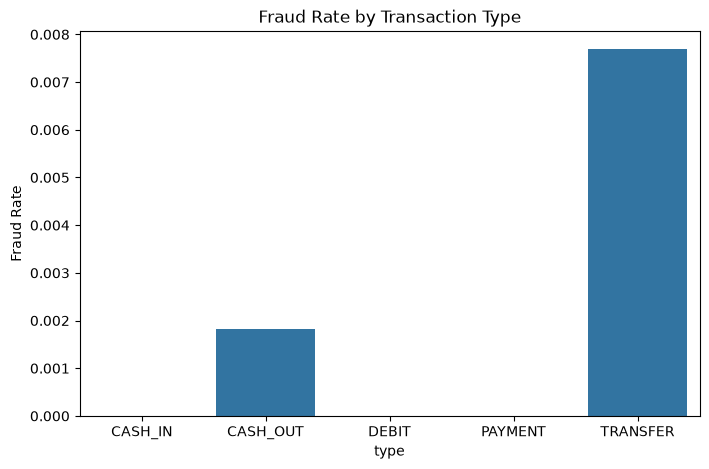

In [42]:
plt.figure(figsize=(8,5))
sns.barplot(x=type_fraud.index, y=type_fraud['mean'])
plt.title('Fraud Rate by Transaction Type')
plt.ylabel('Fraud Rate')
plt.show()

**Amount Distribution**

We can observe that, in this dataset, fraudulent activities tend to involve larger amounts of money compared to non-fraudulent ones. But, since there is overlap between them, this is not absolute, `log_amount` alone cannot reliably classify fraud. However, its distinct distributional shift makes it a strong predictive feature when combined with other indicators in a model.

In [43]:
df_eda['log_amount'] = np.log1p(df_eda['amount'])

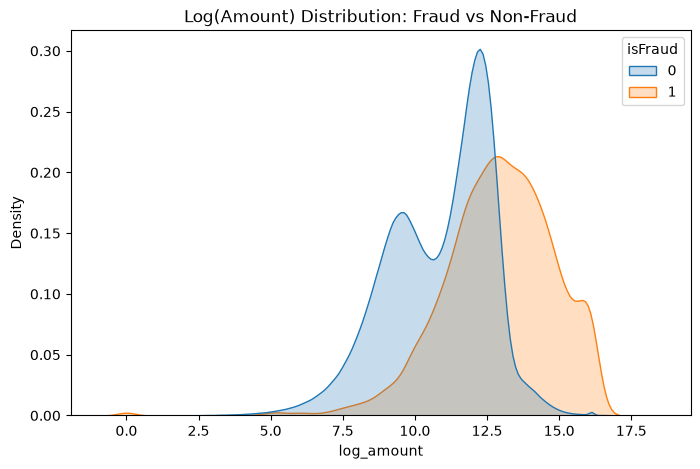

In [44]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_eda, x='log_amount', hue='isFraud', common_norm=False, fill=True)
plt.title('Log(Amount) Distribution: Fraud vs Non-Fraud')
plt.show()

**Correlation HeatMap**

We can observe near-zero `isFraud` values for this HeatMap; this explains that using models may not effectively capture the relationships between variables, suggesting that non-linear algorithms or tree-based models would be better suited for this dataset.

In [45]:
numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']

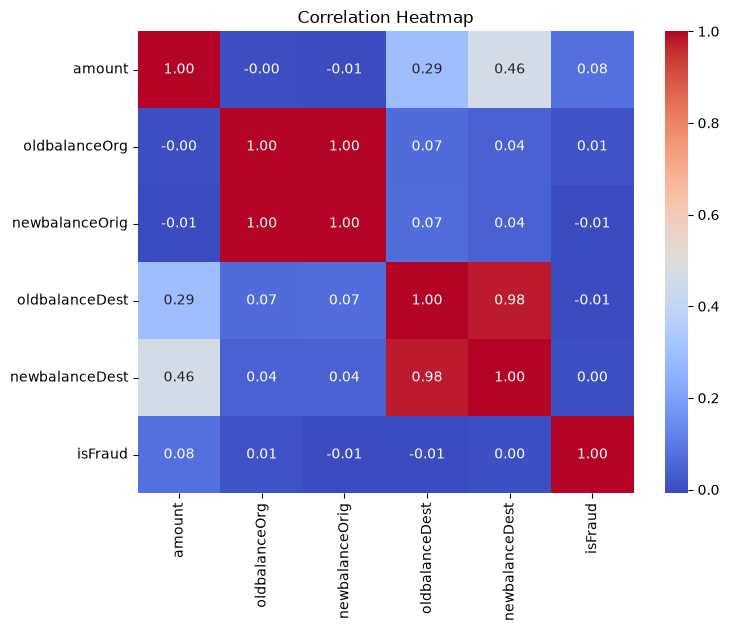

In [46]:
plt.figure(figsize=(8,6))
sns.heatmap(df_eda[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## **Data Cleaning and Pre-processing**